# Random Forest Classification Model

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('./data/UCI_Credit_Card.csv')
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

base_rf = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(estimator=base_rf, param_distributions=param_dist, 
                               n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1,
                               scoring='f1')

print("Starting Randomized Search...")
rf_random.fit(X_train_scaled, y_train_resampled)

print(f"Best Parameters Found: {rf_random.best_params_}")
print(f"Best F1 Score from CV: {rf_random.best_score_:.4f}")

rf_classifier = rf_random.best_estimator_

Starting Randomized Search...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None, 'criterion': 'entropy'}
Best F1 Score from CV: 0.7933


Accuracy: 0.7830

-------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      4673
           1       0.51      0.51      0.51      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.68      0.68      6000
weighted avg       0.78      0.78      0.78      6000

-------------------------------------------------------


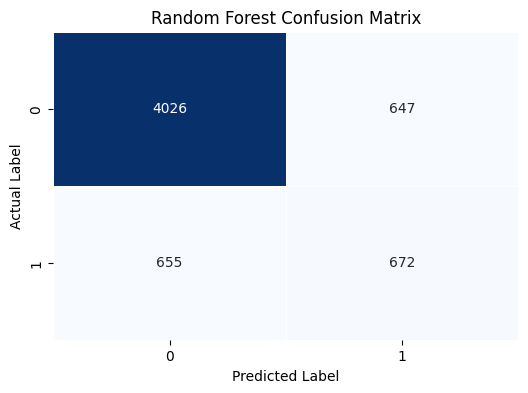

In [12]:
y_pred = rf_classifier.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}\n")
print("-" * 55)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("-" * 55)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Top 10 Feature Ranking:
1. feature PAY_0 (0.0735)
2. feature BILL_AMT1 (0.0584)
3. feature PAY_AMT1 (0.0566)
4. feature LIMIT_BAL (0.0562)
5. feature PAY_2 (0.0535)
6. feature PAY_AMT2 (0.0516)
7. feature BILL_AMT2 (0.0501)
8. feature PAY_AMT3 (0.0496)
9. feature AGE (0.0476)
10. feature PAY_AMT6 (0.0469)


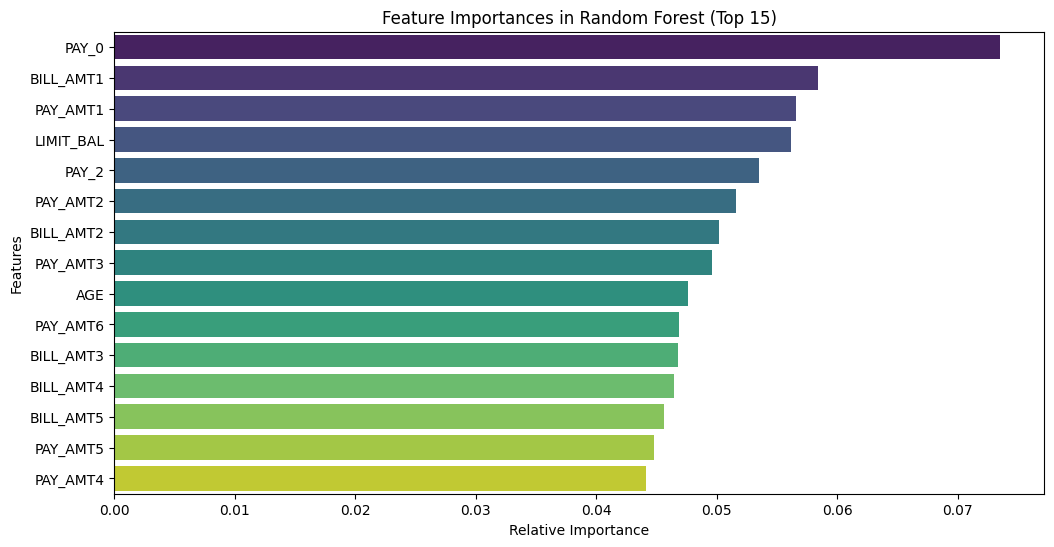

In [13]:
importances = rf_classifier.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

print("Top 10 Feature Ranking:")
for f in range(10):
    print(f"{f + 1}. feature {feature_names[indices[f]]} ({importances[indices[f]]:.4f})")

plt.figure(figsize=(12, 6))
plt.title("Feature Importances in Random Forest (Top 15)")
sns.barplot(x=importances[indices][:15], y=feature_names[indices][:15], palette='viridis')
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.show()